In [36]:
# Импорты и загрузка данных 
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # spearmanr с p-value, для кластеризации в clustermap

sns.set(style='whitegrid')

# Доступ к проектным модулям
if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_worst_corrosion_by_component as load_data

# Загрузка полного датасета (запускать редко — долго)
DF_full = load_data()

In [37]:
# Целевая переменная
TARGET = 'corr_rate_worst_mm_per_year'

assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Полный датасет: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

Полный датасет: 36,093 строк, 62 колонок
Колонки: ['ammonia_content', 'ammonium_chloride_content', 'avg_corr_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component', 'component_id', 'component_type', 'component_type_code', 'contour', 'corr_rate_worst_mm_per_year', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_section_area_mm2', 'curr_measurement_date', 'curr_thickness_avg_mm', 'curr_thickness_worst_mm', 'delta_years', 'effective_start_date', 'equipment', 'equipment_age_years', 'equipment_id', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'initial_thickness', 'inner_diameter', 'installation', 'installation_id', 'material_code', 'material_code_id', 'material_grade', 'material_resistance_score', 'material_type', 'max_corr_rate_mm_per_year', 'min_corr_rate_mm_per_year', 'nominal_eff', 'nominal_thickness_mmc', 'num_points_in_section', 'num_sections', 'out

In [ ]:
def analyze_correlations(columns, title, df=None):
    """Строит матрицу корреляций Спирмена и heatmap по списку параметров.
    columns — список имён параметров, title — название графика."""
    if df is None:
        df = globals().get('DF_loaded', globals().get('DF_full'))
    cols_use = [c for c in columns if c in df.columns]
    df_work = df[cols_use].copy().select_dtypes(include=[np.number]).dropna(how='all', axis=1)
    if df_work.empty or len(df_work.columns) < 2:
        print("Недостаточно числовых столбцов для корреляции.")
        return
    print(f"Параметры: {list(df_work.columns)}\nСтрок: {len(df_work):,}")
    corr_spearman = df_work.corr(method='spearman')
    print("\nМатрица корреляций Спирмена:\n", corr_spearman.round(3))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Новые функции: Pearson clustermap + Spearman vs target
# ---------------------------------------------------------------------------

# Колонки по умолчанию исключаемые из clustermap (портят вид — ID, даты и т.д.)

EXCLUDE_COLS_DEFAULT = [
    'installation_id', 'equipment_id', 'component_id', 'material_code_id',
    'worst_mms_section','max_corr_rate_mm_per_year', 'avg_corr_rate_mm_per_year', 'min_corr_rate_mm_per_year', 'num_sections', 
    'delta_years','prev_thickness_worst_mm','prev_thickness_avg_mm','prev_thickness_avg_mm', 'nominal_thickness_mmc', 'curr_thickness_worst_mm',
    'num_points_in_section','tmin_mmc','curr_thickness_avg_mm'
]
INCLUDE_COLS_DEFAULT = None  # если задан список — используются только эти признаки
INSTALLATION_NAMES = {4: 'KK-2', 51: 'КК', 53: 'АВТ-1', 54: 'АВТ-6', 68: 'АВТ-2', 80: 'АВТ-5'}


def _prepare_numeric_df(df, exclude_cols, include_cols):
    df_num = df.select_dtypes(include=[np.number]).dropna(how='all', axis=1)
    exclude = set(exclude_cols) if exclude_cols else set()
    cols = [c for c in df_num.columns if c not in exclude]
    if include_cols:
        cols = [c for c in include_cols if c in cols]
    return df_num[cols].copy()


def _do_one_clustermap(corr_df, title, threshold, figsize, annot_fontsize=9):
    g = sns.clustermap(
        corr_df,
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        figsize=figsize,
        annot=True, fmt='.2f',
        annot_kws={'size': annot_fontsize},
        linewidths=0.3,
        dendrogram_ratio=(0.12, 0.12),
    )
    g.fig.suptitle(title, y=1.02, fontsize=14)
    plt.show()
    pairs = []
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_df.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({'Признак 1': cols[i], 'Признак 2': cols[j], 'Pearson r': round(r, 3)})
    if pairs:
        df_pairs = pd.DataFrame(pairs).sort_values('Pearson r', key=abs, ascending=False)
        print(f"Мультиколлинеарные пары (|r| >= {threshold}): {len(df_pairs)}")
        display(df_pairs.reset_index(drop=True))
    else:
        print(f"Пар с |r| >= {threshold} не обнаружено.")


def plot_pearson_clustermap(
    df=None,
    exclude_cols=None,
    include_cols=None,
    plot_by_installation=True,
    threshold=0.8,
    figsize=(18, 16),
    annot_fontsize=9,
):
    """Clustermap Пирсона: общий + по каждой установке. exclude_cols — исключить, include_cols — только эти (опционально)."""
    if df is None:
        df = globals().get('DF_loaded', globals().get('DF_full'))
    exclude_cols = exclude_cols if exclude_cols is not None else EXCLUDE_COLS_DEFAULT
    include_cols = include_cols if include_cols is not None else INCLUDE_COLS_DEFAULT

    df_num = _prepare_numeric_df(df, exclude_cols, include_cols)
    if len(df_num.columns) < 2:
        print("Недостаточно признаков.")
        return None
    print(f"Общий: {len(df_num.columns)} признаков, {len(df_num):,} строк")
    corr_all = df_num.corr(method='pearson')
    title = "Пирсон"
    _do_one_clustermap(corr_all, title, threshold, figsize, annot_fontsize)

    if plot_by_installation and 'installation_id' in df.columns:
        for uid in sorted(df['installation_id'].dropna().unique()):
            df_sub = df[df['installation_id'] == uid]
            df_num_sub = _prepare_numeric_df(df_sub, exclude_cols, include_cols)
            if len(df_num_sub.columns) < 2 or len(df_num_sub) < 10:
                continue
            name = INSTALLATION_NAMES.get(uid, str(uid))
            corr_sub = df_num_sub.corr(method='pearson')
            print(f"\nУстановка {name} (id={uid}): {len(df_num_sub.columns)} признаков, {len(df_num_sub):,} строк")
            _do_one_clustermap(corr_sub, f"Пирсон — {name} (id={uid})", threshold, figsize, annot_fontsize)
    return corr_all


def spearman_table(df=None, target=None, exclude_cols=None, include_cols=None):
    """Быстрый табличный анализ по Спирмену: возвращает DataFrame [Признак, Spearman rho].

    Та же логика, что у plot_spearman_vs_target, но без графиков. Сортировка по |rho| убыв.
    """
    if df is None:
        df = globals().get('DF_loaded', globals().get('DF_full'))
    if target is None:
        target = TARGET
    exclude_cols = exclude_cols if exclude_cols is not None else EXCLUDE_COLS_DEFAULT
    include_cols = include_cols if include_cols is not None else INCLUDE_COLS_DEFAULT

    df_num = _prepare_numeric_df(df, exclude_cols, include_cols)
    if target not in df_num.columns and target in df.columns:
        df_num = df_num.copy()
        df_num[target] = df[target]
    features = [c for c in df_num.columns if c != target]

    results = []
    for feat in features:
        mask = df_num[[feat, target]].dropna().index
        x = df_num.loc[mask, feat]
        y_sub = df_num.loc[mask, target]
        if len(x) < 3:
            continue
        rho, _ = stats.spearmanr(x, y_sub)
        results.append({'Признак': feat, 'Spearman rho': round(rho, 4)})

    df_res = pd.DataFrame(results).sort_values('Spearman rho', key=lambda c: abs(c), ascending=False).reset_index(drop=True)
    return df_res


def plot_spearman_vs_target(df=None, target=None, exclude_cols=None, include_cols=None, alpha=0.05, figsize=(10, None)):
    """Ранжирование признаков по корреляции Спирмена с целевой.

    exclude_cols — исключить; include_cols — только эти (опционально).
    """
    df_res = spearman_table(df, target, exclude_cols, include_cols)
    if df_res.empty:
        print("Нет данных для графика.")
        return df_res
    t = target or TARGET
    df_num = _prepare_numeric_df(df, exclude_cols or EXCLUDE_COLS_DEFAULT, include_cols or INCLUDE_COLS_DEFAULT)
    if t not in df_num.columns and t in df.columns:
        df_num = df_num.copy()
        df_num[t] = df[t]
    # Добавляем p-value и значимость для отображения
    for i, row in df_res.iterrows():
        mask = df_num[[row['Признак'], t]].dropna().index
        if len(mask) >= 3:
            _, pval = stats.spearmanr(df_num.loc[mask, row['Признак']], df_num.loc[mask, t])
            df_res.loc[i, 'p-value'] = pval
            df_res.loc[i, 'Значимый'] = 'Да' if pval < alpha else 'Нет'
    df_res['|rho|'] = df_res['Spearman rho'].abs()
    print(f"Корреляция Спирмена каждого признака с «{t}» (alpha={alpha})")
    display(df_res)

    # --- Горизонтальный bar-chart ---
    df_plot = df_res.sort_values('|rho|', ascending=True)  # снизу слабые, сверху сильные
    height = figsize[1] if figsize[1] else max(6, len(df_plot) * 0.4)
    fig, ax = plt.subplots(figsize=(figsize[0], height))

    colors = ['#d62728' if v < 0 else '#1f77b4' for v in df_plot['Spearman rho']]
    ax.barh(df_plot['Признак'], df_plot['Spearman rho'], color=colors, edgecolor='none')
    ax.set_xlabel('Spearman ρ')
    ax.set_title(f'Корреляция Спирмена признаков с «{t}»')
    ax.axvline(0, color='grey', linewidth=0.8)

    # Отметка незначимых
    for idx, row in df_plot.iterrows():
        if row['Значимый'] == 'Нет':
            y_pos = list(df_plot['Признак']).index(row['Признак'])
            ax.annotate('n.s.', xy=(row['Spearman rho'], y_pos),
                        fontsize=8, color='grey', va='center', ha='left' if row['Spearman rho'] >= 0 else 'right')

    plt.tight_layout()
    plt.show()

    return df_res

In [48]:
# Фильтр по установкам: новая переменная — быстрый перезапуск без повторной загрузки
# 54 - АВТ-6
# 68 - АВТ-2
# 53 - АВТ-1
# 80 - АВТ-5
# corrosion_aggressiveness_index                        0.141
# h2s_content                                           0.101
# 4 - KK-2
# 51- КК
INSTALLATION_IDS = [4,51,80,53,68,54]  # Список ID установок для фильтрации 


# Фильтрация по списку установок
DF_loaded = DF_full[DF_full['installation_id'].isin(INSTALLATION_IDS)].copy()
DF_loaded = DF_loaded.sort_values('installation_id').reset_index(drop=True)
print(f"Отфильтровано (installation_id in {INSTALLATION_IDS}): {len(DF_loaded):,} строк")

# Только неотрицательная целевая переменная
# DF_loaded = DF_loaded[DF_loaded[TARGET] >= 0]
# print(f"После отбора строк с {TARGET} >= 0: {len(DF_loaded):,} строк")

# Пустые в числовых признаках = 0; цель не заполняем
num_cols = [c for c in DF_loaded.select_dtypes(include=[np.number]).columns if c != TARGET]
DF_loaded[num_cols] = DF_loaded[num_cols].fillna(0)

print(f"Распределение по установкам:")
print(DF_loaded['installation_id'].value_counts().sort_index())

Отфильтровано (installation_id in [4, 51, 80, 53, 68, 54]): 36,093 строк
Распределение по установкам:
installation_id
4     6951
51    7529
53    3908
54    9929
68    3772
80    4004
Name: count, dtype: int64


In [59]:
# Корреляция Спирмена каждого признака с целевой переменной
# exclude_cols и include_cols — как в clustermap выше
#plot_spearman_vs_target(
#    DF_loaded,
#    exclude_cols=EXCLUDE_COLS_DEFAULT,
#    include_cols=INCLUDE_COLS_DEFAULT,
#    alpha=0.05,
#)
# Только KK-2 и КК:
df_sub = DF_loaded[DF_loaded['installation_id'].isin([68])]
spearman_table(df_sub)


C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)


,Признак,Spearman rho
0,curr_thickness_avg_mm,-0.1427
1,inner_diameter,-0.0794
2,outer_diameter,-0.0694
3,tmin_eff,-0.0646
4,cross_section_area_mm2,-0.0581
5,material_resistance_score,-0.0528
6,total_acidity_index,0.0366
7,oxygen_content,0.0329
8,water_content,-0.0299
9,total_chlorine_compounds,0.0290


In [ ]:

# Матрица корреляций Пирсона — clustermap (общий + по каждой установке)
# Исключаемые колонки задаются в EXCLUDE_COLS_DEFAULT выше (ID установок, компонентов и т.д.)
# Опционально: INCLUDE_COLS_DEFAULT = ['water_content', 'h2s_content', ...] — только эти признаки

# Можно дополнить EXCLUDE_COLS_DEFAULT или задать include_cols:
# Фильтрацию по установкам делайте снаружи, например: plot_pearson_clustermap(DF_loaded[DF_loaded['installation_id'].isin([4, 51])])

#plot_pearson_clustermap(
#    DF_loaded,
#    exclude_cols=EXCLUDE_COLS_DEFAULT,
#    include_cols=INCLUDE_COLS_DEFAULT,
#    plot_by_installation=True,
#    threshold=0.8,
#    annot_fontsize=9,
#)

C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Users\admin\AppData\Local\Temp\ipykernel_11936\359295229.py:135: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = stats.spearmanr(x, y_sub)
C:\Us

,Признак,Spearman rho
0,nominal_eff,0.1973
1,initial_thickness,0.1900
2,total_components,0.1713
3,cross_section_area_mm2,0.1687
4,component_type_code,-0.1661
5,tmin_eff,0.1624
6,outer_diameter,0.1458
7,corrosion_aggressiveness_index,0.1260
8,inner_diameter,0.1250
9,stress_corrosion_index,0.1209


Параметры: ['corr_rate_worst_mm_per_year', 'equipment_age_years', 'chloride_aggressiveness', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'material_resistance_score']
Строк: 36,093

Матрица корреляций Спирмена:
                                 corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                           1.000   
equipment_age_years                                  -0.132   
chloride_aggressiveness                               0.009   
corrosion_aggressiveness_index                        0.067   
corrosion_inhibitor_content                          -0.007   
material_resistance_score                            -0.013   

                                equipment_age_years  chloride_aggressiveness  \
corr_rate_worst_mm_per_year                  -0.132                    0.009   
equipment_age_years                           1.000                    0.136   
chloride_aggressiveness                       0.136                    1.000   
corros

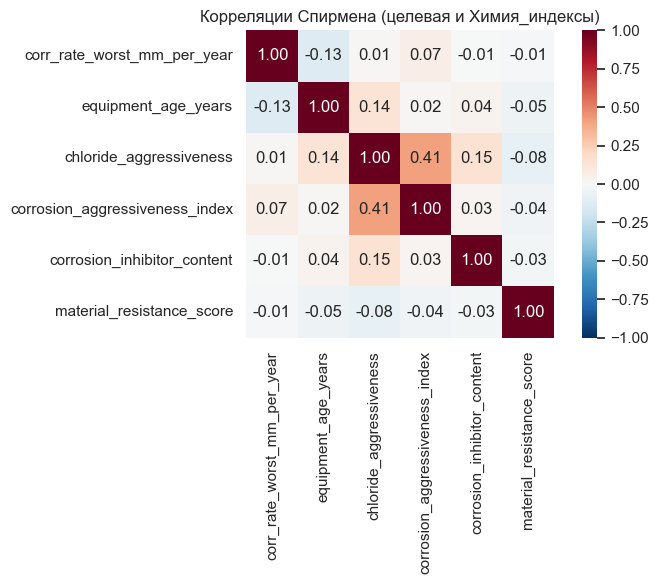

Параметры: ['corr_rate_worst_mm_per_year', 'ammonia_content', 'ammonium_chloride_content', 'chlorine_content', 'co2_content', 'corrosion_inhibitor_content', 'h2s_content', 'hydrochloric_acid_content', 'oxygen_content', 'sodium_hydroxide_content', 'water_content']
Строк: 36,093

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  ammonia_content  \
corr_rate_worst_mm_per_year                        1.000            0.034   
ammonia_content                                    0.034            1.000   
ammonium_chloride_content                          0.025           -0.008   
chlorine_content                                   0.026            0.557   
co2_content                                        0.034           -0.067   
corrosion_inhibitor_content                       -0.007           -0.013   
h2s_content                                        0.070            0.227   
hydrochloric_acid_content                         -0.005           -0.022  

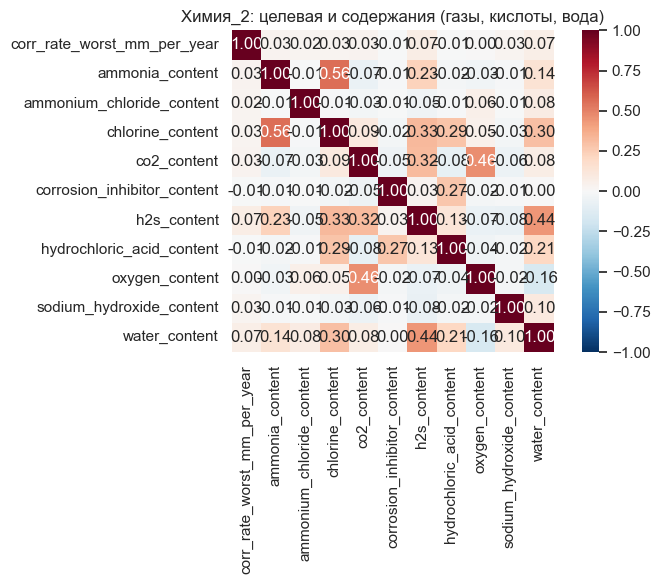

Параметры: ['corr_rate_worst_mm_per_year', 'corrosion_protection_index', 'h2s_aggressiveness_index', 'h2s_water_ratio', 'pitting_corrosion_index', 'stress_corrosion_index', 'underdeposit_corrosion_index']
Строк: 36,093

Матрица корреляций Спирмена:
                               corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                         1.000   
corrosion_protection_index                          0.038   
h2s_aggressiveness_index                            0.064   
h2s_water_ratio                                     0.063   
pitting_corrosion_index                             0.025   
stress_corrosion_index                              0.072   
underdeposit_corrosion_index                        0.043   

                              corrosion_protection_index  \
corr_rate_worst_mm_per_year                        0.038   
corrosion_protection_index                         1.000   
h2s_aggressiveness_index                           0.144   
h2s_water_ratio      

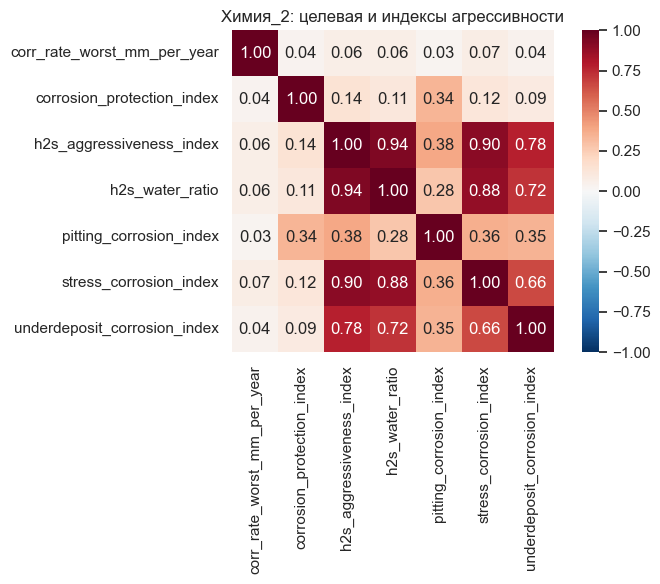

Параметры: ['corr_rate_worst_mm_per_year', 'total_acidity_index', 'total_acids', 'total_chlorine_compounds', 'total_sulfur_compounds']
Строк: 36,093

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  total_acidity_index  \
corr_rate_worst_mm_per_year                        1.000                0.030   
total_acidity_index                                0.030                1.000   
total_acids                                        0.034                0.925   
total_chlorine_compounds                           0.010                0.278   
total_sulfur_compounds                             0.020                0.009   

                             total_acids  total_chlorine_compounds  \
corr_rate_worst_mm_per_year        0.034                     0.010   
total_acidity_index                0.925                     0.278   
total_acids                        1.000                     0.056   
total_chlorine_compounds           0.056             

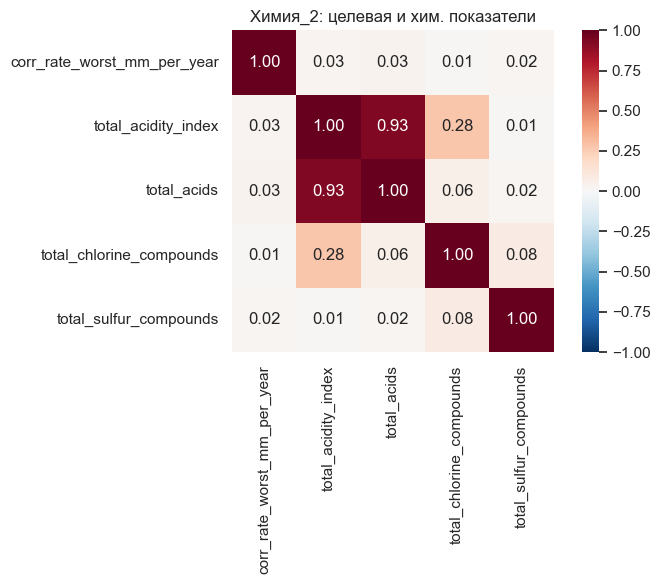

Параметры: ['corr_rate_worst_mm_per_year', 'cross_section_area_mm2', 'inner_diameter', 'nominal_thickness_mmc', 'outer_diameter']
Строк: 36,093

Матрица корреляций Спирмена:
                              corr_rate_worst_mm_per_year  \
corr_rate_worst_mm_per_year                        1.000   
cross_section_area_mm2                             0.053   
inner_diameter                                     0.033   
nominal_thickness_mmc                              0.073   
outer_diameter                                     0.043   

                             cross_section_area_mm2  inner_diameter  \
corr_rate_worst_mm_per_year                   0.053           0.033   
cross_section_area_mm2                        1.000           0.956   
inner_diameter                                0.956           1.000   
nominal_thickness_mmc                         0.924           0.802   
outer_diameter                                0.985           0.991   

                             nominal_

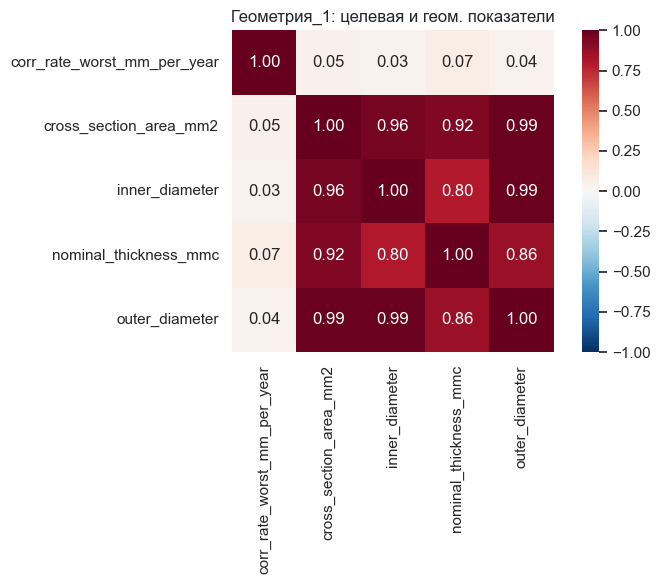

In [ ]:
COLS = [
    'corr_rate_worst_mm_per_year',
    'equipment_age_years',
    'chloride_aggressiveness',
    'corrosion_aggressiveness_index',
    'corrosion_inhibitor_content',
    'material_resistance_score',

]
#analyze_correlations(COLS, 'Корреляции Спирмена (целевая и Химия_индексы)')

# Блок 1: целевая + содержания (газы, кислоты, вода)
COLS_1 = [
    'corr_rate_worst_mm_per_year',
    'ammonia_content',
    'ammonium_chloride_content',
    'chlorine_content',
    'co2_content',
    'corrosion_inhibitor_content',
    'h2s_content',
    'hydrochloric_acid_content',
    'oxygen_content',
    'sodium_hydroxide_content',
    'water_content',
]
#analyze_correlations(COLS_1, 'Химия_2: целевая и содержания (газы, кислоты, вода)')

# Блок 2: целевая + индексы агрессивности
COLS_2 = [
    'corr_rate_worst_mm_per_year',
    'corrosion_protection_index',
    'h2s_aggressiveness_index',
    'h2s_water_ratio',
    'pitting_corrosion_index',
    'stress_corrosion_index',
    'underdeposit_corrosion_index',
]
#analyze_correlations(COLS_2, 'Химия_2: целевая и индексы агрессивности')

# Блок 3: целевая + суммарные показатели и кислотность
COLS_3 = [
    'corr_rate_worst_mm_per_year',
    'total_acidity_index',
    'total_acids',
    'total_chlorine_compounds',
    'total_sulfur_compounds',
]
#analyze_correlations(COLS_3, 'Химия_2: целевая и хим. показатели')

COLS_4 = [
    'corr_rate_worst_mm_per_year',
    'cross_section_area_mm2',
    'inner_diameter',
    'nominal_thickness_mmc',
    'outer_diameter',
    'material_grade'
    ]

#analyze_correlations(COLS_4, 'Геометрия_1: целевая и геом. показатели')
